# Section 4.5 — Repetitive tool-call loops

This notebook reconstructs the repetitive-call analysis used in Section `4.5` directly from the released `results/` bundles.

Running all cells will:
- measure how often each planner repeats the same consecutive tool call with identical arguments
- reproduce the high-robustness and low-robustness rate tables discussed in the paper
- visualize the `SH` minus `FH` repetition gap
- surface one concrete released example that shows the loop behavior

In [9]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks.posthoc_results import (
    DATASET_LABEL_ORDER,
    MODEL_ORDER,
    PLANNER_ORDER,
    load_episode_results,
    load_question_runs,
)

sns.set_theme(style="whitegrid", context="talk")
episodes = load_episode_results(include_steps=False)
episodes.head()

,dataset,dataset_label,planner,model,robustness,robustness_label,run_id,result_dir,question_id,question_text,final_output,success,evaluation_label,is_correct,total_steps,repetitive_count
0,kqa_pro,KQA Pro,FH,GPT-4.1-mini,high,High robustness,2026-01-06-22-16-13,pne.gpt-4p1-mini.json.v1.retries-8,val_0000,What country does University of Oxford's head...,England,True,correct,True,4,0
1,kqa_pro,KQA Pro,FH,GPT-4.1-mini,high,High robustness,2026-01-06-22-16-13,pne.gpt-4p1-mini.json.v1.retries-8,val_0001,At which street address did the death of Anne ...,No street address information is available for...,True,refusal/unsure,False,20,0
2,kqa_pro,KQA Pro,FH,GPT-4.1-mini,high,High robustness,2026-01-06-22-16-13,pne.gpt-4p1-mini.json.v1.retries-8,val_0002,Tell me when Lon Chaney Jr. was born.,1906-02-10,True,correct,True,3,0
3,kqa_pro,KQA Pro,FH,GPT-4.1-mini,high,High robustness,2026-01-06-22-16-13,pne.gpt-4p1-mini.json.v1.retries-8,val_0003,What is Chris Elliott's birth date?,1960-05-31,True,correct,True,3,0
4,kqa_pro,KQA Pro,FH,GPT-4.1-mini,high,High robustness,2026-01-06-22-16-13,pne.gpt-4p1-mini.json.v1.retries-8,val_0004,"Which covers a larger amount of area, Key West...",Billings,True,correct,True,4,0


In [6]:
run_summary = (
    episodes.groupby(
        ["dataset_label", "planner", "model", "robustness", "run_id"]
    )
    .agg(
        total_episodes=("question_id", "count"),
        episodes_with_repetition=(
            "repetitive_count",
            lambda series: int((series > 0).sum()),
        ),
        avg_repetition_when_present=(
            "repetitive_count",
            lambda series: float(series[series > 0].mean())
            if (series > 0).any()
            else 0.0,
        ),
    )
    .reset_index()
)
run_summary["episodes_with_repetition_pct"] = (
    run_summary["episodes_with_repetition"]
    / run_summary["total_episodes"]
    * 100.0
)

summary = (
    run_summary.groupby(["dataset_label", "planner", "model", "robustness"])
    .agg(
        total_episodes=("total_episodes", "mean"),
        episodes_with_repetition_pct=(
            "episodes_with_repetition_pct",
            "mean",
        ),
        avg_repetition_when_present=(
            "avg_repetition_when_present",
            "mean",
        ),
    )
    .reset_index()
)

for column, categories in {
    "dataset_label": DATASET_LABEL_ORDER,
    "model": MODEL_ORDER,
    "planner": PLANNER_ORDER,
}.items():
    summary[column] = pd.Categorical(
        summary[column],
        categories=categories,
        ordered=True,
    )

summary = summary.sort_values(["robustness", "dataset_label", "model", "planner"])

high_table = (
    summary[summary["robustness"] == "high"]
    .pivot_table(
        index=["dataset_label", "model"],
        columns="planner",
        values="episodes_with_repetition_pct",
        observed=False,
    )
)
high_table.style.format("{:.1f}%")

In [7]:
low_table = (
    summary[summary["robustness"] == "low"]
    .pivot_table(
        index=["dataset_label", "model"],
        columns="planner",
        values="episodes_with_repetition_pct",
        observed=False,
    )
)
low_table.style.format("{:.1f}%")

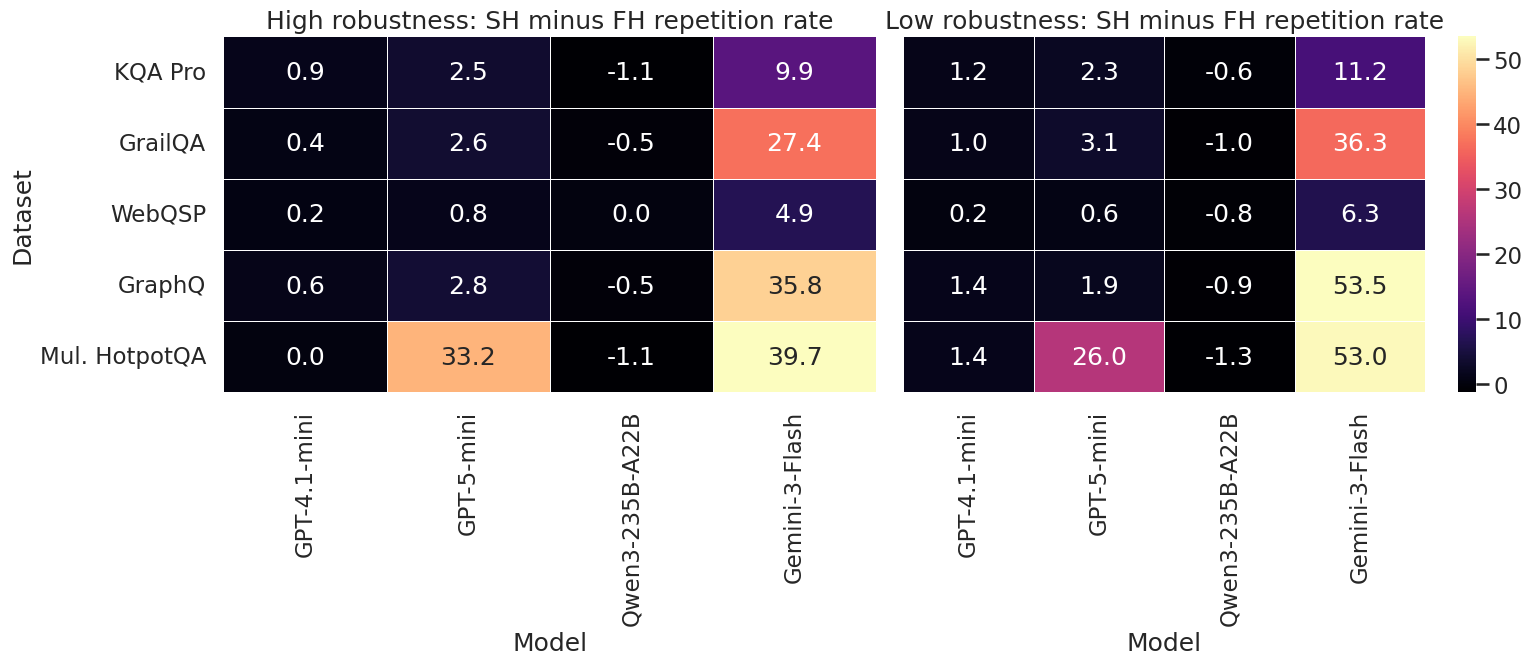

In [8]:
gap_summary = (
    summary.pivot_table(
        index=["dataset_label", "model", "robustness"],
        columns="planner",
        values="episodes_with_repetition_pct",
        observed=False,
    )
    .reset_index()
)
gap_summary["SH minus FH"] = gap_summary["SH"] - gap_summary["FH"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for axis, robustness in zip(axes, ["high", "low"]):
    heatmap_data = (
        gap_summary[gap_summary["robustness"] == robustness]
        .pivot(index="dataset_label", columns="model", values="SH minus FH")
        .loc[DATASET_LABEL_ORDER, MODEL_ORDER]
    )
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap="magma",
        linewidths=0.5,
        cbar=robustness == "low",
        ax=axis,
    )
    axis.set_title(f"{robustness.title()} robustness: SH minus FH repetition rate")
    axis.set_xlabel("Model")
    if axis is axes[0]:
        axis.set_ylabel("Dataset")
    else:
        axis.set_ylabel("")

plt.tight_layout()

In [5]:
case_candidates = (
    episodes[
        (episodes["dataset"] == "multiobj_hotpotqa")
        & (episodes["model"] == "Gemini-3-Flash")
        & (episodes["planner"] == "SH")
        & (episodes["robustness"] == "low")
    ]
    .sort_values(["repetitive_count", "total_steps"], ascending=False)
)
case_question_id = case_candidates.iloc[0]["question_id"]

def format_steps(record: dict[str, object], limit: int = 8) -> pd.DataFrame:
    rows = []
    for index, step in enumerate(record["steps"][:limit]):
        action = step.get("data", {}).get("action", {})
        observation = step.get("data", {}).get("observation", "")
        rows.append(
            {
                "step": index,
                "tool": action.get("name"),
                "arguments": action.get("arguments"),
                "observation_excerpt": str(observation).replace("\n", " ")[:160],
            }
        )
    return pd.DataFrame(rows)

sh_runs = load_question_runs(
    dataset="multiobj_hotpotqa",
    planner="SH",
    model_name="Gemini-3-Flash",
    robustness="low",
    question_id=case_question_id,
)
fh_runs = load_question_runs(
    dataset="multiobj_hotpotqa",
    planner="FH",
    model_name="Gemini-3-Flash",
    robustness="low",
    question_id=case_question_id,
)

selected_sh = max(sh_runs, key=lambda row: row["repetitive_count"])
selected_fh = min(fh_runs, key=lambda row: row["repetitive_count"])

print(f"Case-study question id: {case_question_id}")
print(selected_sh["question_text"])
print()
print(
    "SH run:",
    selected_sh["run_id"],
    "| repetition count:",
    selected_sh["repetitive_count"],
    "| final output:",
    selected_sh["final_output"],
)
display(format_steps(selected_sh))

print(
    "FH run:",
    selected_fh["run_id"],
    "| repetition count:",
    selected_fh["repetitive_count"],
    "| final output:",
    selected_fh["final_output"],
)
display(format_steps(selected_fh))

Case-study question id: test_k1_0056
When did British politician Damian Green state that said that e-Borders would be collecting information an all passengers on 100% of non-EEA flights to the UK?

SH run: 2026-01-23-22-09-02 | repetition count: 29 | final output: Maximum steps (30) reached


,step,tool,arguments,observation_excerpt
0,0,search,{'question': 'When did Damian Green state that...,# Found the answer: March 2012 $0 = search[{'q...
1,1,search,{'question': 'When did Damian Green state that...,# Found the answer: March 2012 $1 = search[{'q...
2,2,search,{'question': 'When did Damian Green state that...,# Found the answer: March 2012 $2 = search[{'q...
3,3,search,{'question': 'When did Damian Green state that...,# Found the answer: March 2012 $3 = search[{'q...
4,4,search,{'question': 'When did Damian Green state that...,# Found the answer: March 2012 $4 = search[{'q...
5,5,search,{'question': 'When did Damian Green state that...,# Found the answer: March 2012 $5 = search[{'q...
6,6,search,{'question': 'When did Damian Green state that...,# Found the answer: March 2012 $6 = search[{'q...
7,7,search,{'question': 'When did Damian Green state that...,# Found the answer: March 2012 $7 = search[{'q...


FH run: 2026-01-23-19-31-44 | repetition count: 0 | final output: ['March 2012']


,step,tool,arguments,observation_excerpt
0,0,search,{'question': 'When did Damian Green state that...,# Found the answer: March 2012 $0 = search[{'q...
1,1,finish,{'answer': ['$0']},['March 2012']


## How this supports Section 4.5

- The first two tables reproduce the paper's key summary: repeated calls are rare for `FH`, but can become common for `SH`, especially with `Gemini-3-Flash` and `GPT-5-mini`.
- The heatmaps make the planner gap easier to scan: brighter cells mark settings where `SH` loops far more often than `FH`.
- The case-study cell surfaces one released example automatically, so readers can inspect the actual repeated tool calls instead of relying only on aggregate rates.
- The notebook reads the raw released trajectories directly, so it stays aligned with the repository artifact instead of a stale exported CSV.